## EDA (Exploratory Data Analysis)

In [1]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Load Dataset
df = pd.read_csv("../data/processed/Cleaned-Telco-Customer-Churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Tenure & Customer Lifecycle Analysis

### 1. What is the churn rate in the first 3, 6, and 12 months?

In [3]:
## Segment the customer based on tenure
tenure_churn_data = []
tenure_month = [3,6,12]
for month in tenure_month:
    mask = (df['tenure']<=month)
    temp_df = df[mask]['Churn']
    tenure_churn_data.append({"tenure": ' <= '+ str(month), 'Churn_Rate': (temp_df.value_counts(normalize=True)['Yes']*100).round(2)})

tenure_wise_churn_rate = pd.DataFrame(data=tenure_churn_data) 
tenure_wise_churn_rate


,tenure,Churn_Rate
0,<= 3,56.76
1,<= 6,53.30
2,<= 12,47.65


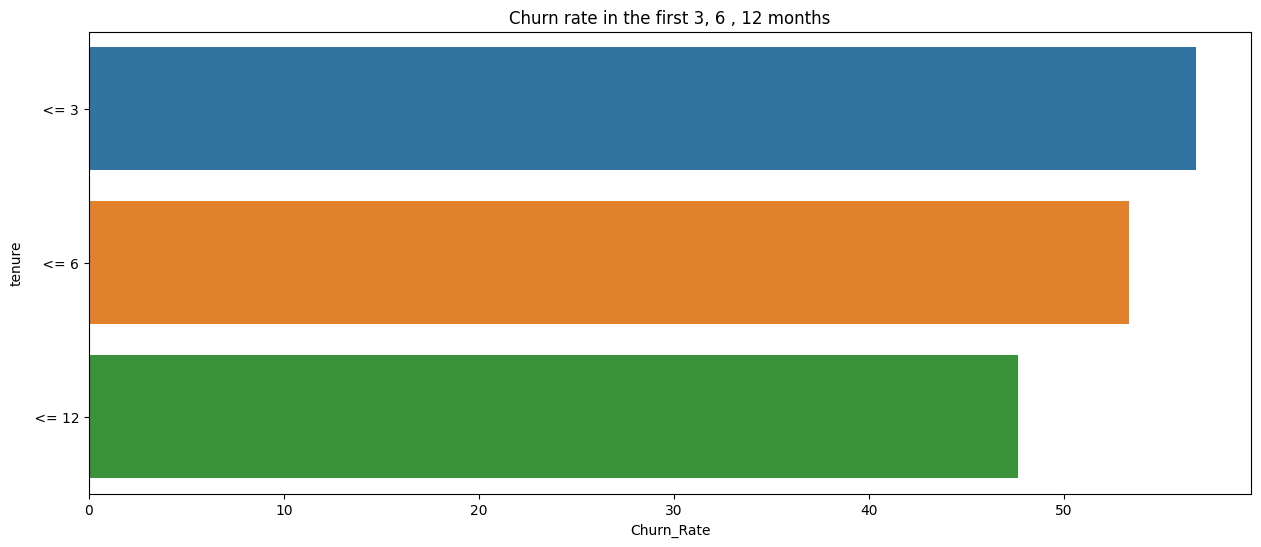

In [4]:
## Visualization
plt.figure(figsize=(15,6))
sns.barplot(data=tenure_wise_churn_rate, x='Churn_Rate', y='tenure', orient='h', hue='tenure')
plt.title("Churn rate in the first 3, 6 , 12 months")
plt.show()

#### Comments:
* The churn rate is highest in the first 3 months (56.76%) 
* The churn rate decreases significantly after the first 3 months, dropping to 53.30% in the <= 6 month range and further to 47.65% in the <= 12 month range.

### 2. At what tenure does churn stabilize?

Divide the customers in the base of tenure into multiple groups:
* (0-6)
* (7-12)
* (13-18)
* (19-24)
* (25-30)
* (31-36)
* (37-42)
* (43-48)
* (49-54)
* (55-60)
* (61-66)
* (66+)

In [5]:
## Segmentation 
df['Tenure_Group'] = pd.cut(
    x = df['tenure'],
    bins=[0,6,12,18,24,30,36,42,48,54,60,66,72],
    labels=['0-6', '7-12', '13-18', '19-24', '25-30', '31-36', '37-42', '43-48', '49-54', '55-60', '61-66', '67+'],
    right=True
)

## Create df of each group with churn rate
tenure_group_wise_churn = df.groupby(['Tenure_Group'], observed=True)['Churn'].agg([lambda x: ((x=='Yes').mean()*100).round(2), 'count'])
tenure_group_wise_churn.columns = ['Churn_Rate', 'Customers']
tenure_group_wise_churn

,Churn_Rate,Customers
Tenure_Group,,
0-6,53.30,1469
7-12,35.89,705
13-18,32.23,546
19-24,24.58,476
25-30,21.73,428
31-36,21.45,401
37-42,21.90,379
43-48,16.19,383
49-54,16.19,420


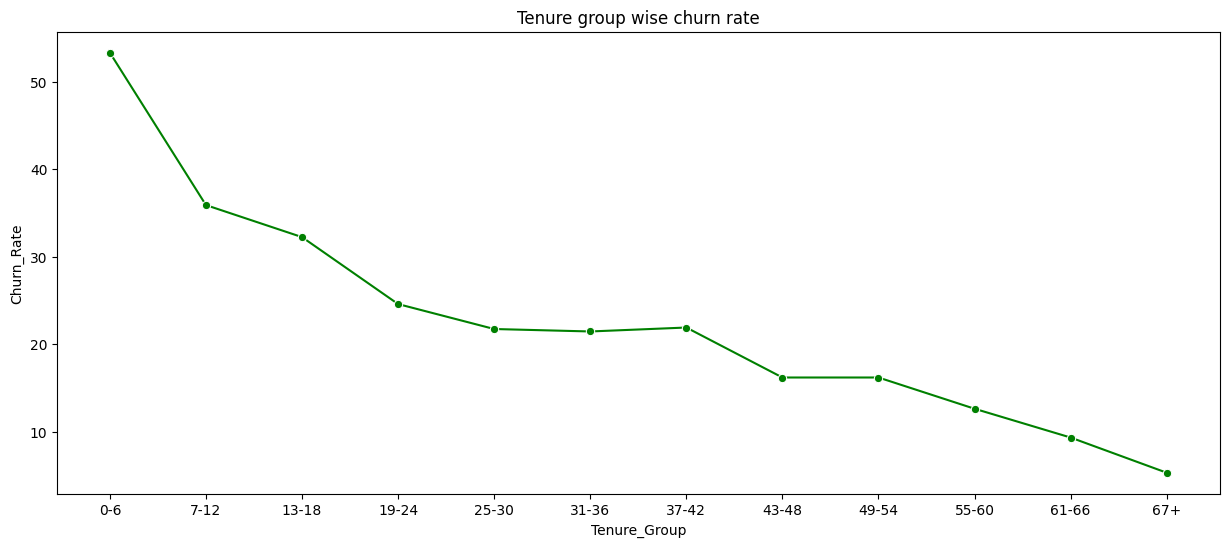

In [6]:
## Visualization
plt.figure(figsize=(15,6))
sns.lineplot(data=tenure_group_wise_churn, x='Tenure_Group', y='Churn_Rate', marker='o', color='g')
plt.title('Tenure group wise churn rate');


#### Comments:
* The churn rate stabilizes 24-42 months tenure range (around 21%).

### 3. Do long-tenure customers churn less despite higher monthly charges?
**Yes**, long-tenure customers tend to churn less even with higher monthly charges.

### 4. Is early-stage churn responsible for most customer loss?

In [7]:
tenure_group_wise_churn

,Churn_Rate,Customers
Tenure_Group,,
0-6,53.30,1469
7-12,35.89,705
13-18,32.23,546
19-24,24.58,476
25-30,21.73,428
31-36,21.45,401
37-42,21.90,379
43-48,16.19,383
49-54,16.19,420


In [8]:
tenure_group_wise_churn['Churned_Customer'] = ((tenure_group_wise_churn['Customers']*tenure_group_wise_churn['Churn_Rate'])/100).round(0)
tenure_group_wise_churn

,Churn_Rate,Customers,Churned_Customer
Tenure_Group,,,
0-6,53.30,1469,783.0
7-12,35.89,705,253.0
13-18,32.23,546,176.0
19-24,24.58,476,117.0
25-30,21.73,428,93.0
31-36,21.45,401,86.0
37-42,21.90,379,83.0
43-48,16.19,383,62.0
49-54,16.19,420,68.0


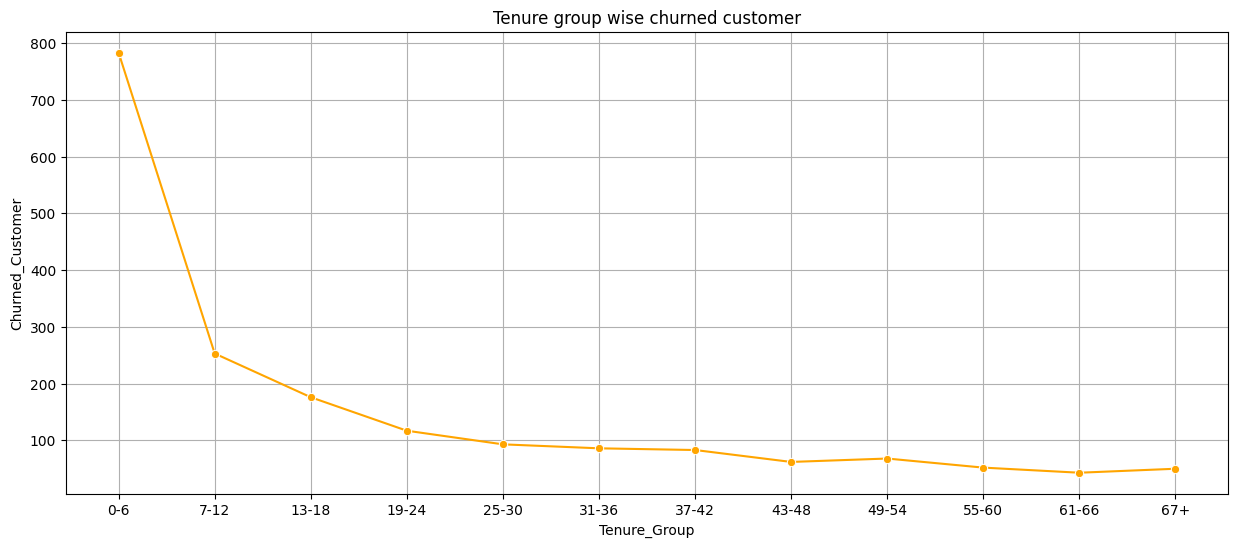

In [9]:
plt.figure(figsize=(15,6))
sns.lineplot(data=tenure_group_wise_churn, x='Tenure_Group', y='Churned_Customer', marker='o', color='orange')
plt.title('Tenure group wise churned customer')
plt.grid()

#### Comments:
Yes, early-stage churn (within the first 6 months) accounts for a significant portion of overall customer loss, indicating that customers are more likely to leave during this initial period.

### 5. How does service adoption change with tenure?
From above analysis, we can divide the tenure into 4 effective groups:
* '0-6 months'
* '6-12 months'
* '12-24 months'
* '24+ months'

In [10]:
## Tenure groups
tenure_bins = [0, 6, 12, 24, 100]
tenure_labels = ['0-6 months', '6-12 months', '12-24 months', '24+ months']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=tenure_bins,
    labels=tenure_labels,
    right=False
)

df['tenure_group']

0        0-6 months
1        24+ months
2        0-6 months
3        24+ months
4        0-6 months
           ...     
7016     24+ months
7017     24+ months
7018    6-12 months
7019     0-6 months
7020     24+ months
Name: tenure_group, Length: 7021, dtype: category
Categories (4, object): ['0-6 months' < '6-12 months' < '12-24 months' < '24+ months']

In [11]:
## Encode services columns
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].map(lambda x: 1 if x=='Yes' else 0)

In [12]:
## Calculate service adoption Rate by tenure group
service_adoption = (
    df.groupby('tenure_group', observed=False)[service_cols]
    .mean().round(4)
    .reset_index()
)

service_adoption

,tenure_group,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0-6 months,0.8992,0.1950,0.0920,0.1354,0.1155,0.1015,0.1884,0.1840
1,6-12 months,0.9054,0.2736,0.1734,0.1819,0.2020,0.1605,0.2808,0.2980
2,12-24 months,0.9100,0.3569,0.2115,0.2431,0.2469,0.2153,0.3225,0.3167
3,24+ months,0.9025,0.5440,0.3935,0.4733,0.4731,0.3978,0.4866,0.4935


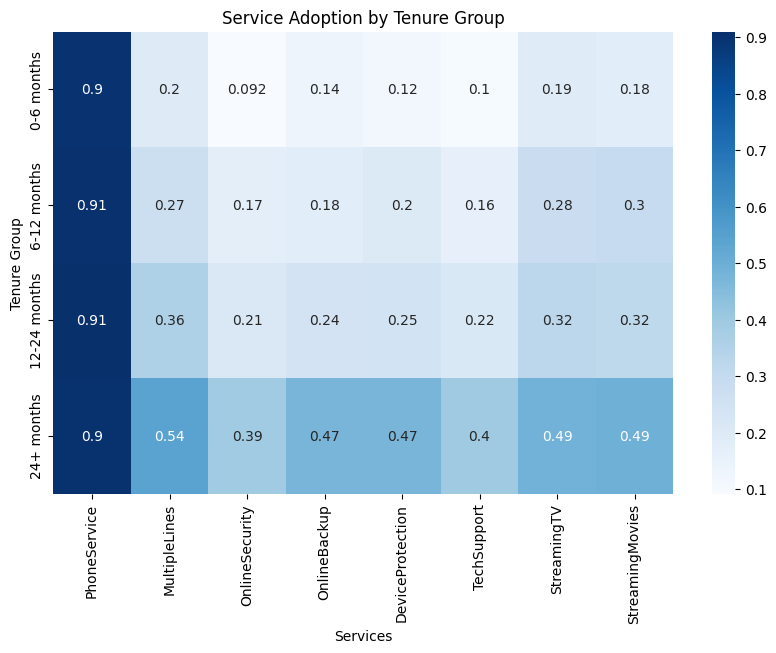

In [13]:
## Visualize Adoption Trend
plt.figure(figsize=(10, 6))
sns.heatmap(
    service_adoption.set_index('tenure_group')[service_cols],
    annot=True,
    cmap='Blues'
)
plt.title("Service Adoption by Tenure Group")
plt.ylabel("Tenure Group")
plt.xlabel("Services")
plt.show()

#### Comments:
It shows a clear view of how service adoption increases with tenure. Customers with longer tenure tend to adopt more services, indicating a positive correlation between tenure and service adoption.

In [14]:
df['total_services'] = df[service_cols].sum(axis=1)

avg_services = (
    df.groupby('tenure_group', observed=True)['total_services']
    .mean().round(2)
    .reset_index()
)

avg_services

,tenure_group,total_services
0,0-6 months,1.91
1,6-12 months,2.48
2,12-24 months,2.82
3,24+ months,4.16


#### Comment:
It shows that high tenure customers uses several services.

In [15]:
## Merge Adoption Metrics
adoption_summary = pd.merge(
    service_adoption,
    avg_services,
    on='tenure_group'
)

adoption_summary

,tenure_group,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,total_services
0,0-6 months,0.8992,0.1950,0.0920,0.1354,0.1155,0.1015,0.1884,0.1840,1.91
1,6-12 months,0.9054,0.2736,0.1734,0.1819,0.2020,0.1605,0.2808,0.2980,2.48
2,12-24 months,0.9100,0.3569,0.2115,0.2431,0.2469,0.2153,0.3225,0.3167,2.82
3,24+ months,0.9025,0.5440,0.3935,0.4733,0.4731,0.3978,0.4866,0.4935,4.16


In [16]:
churn_by_services = (
    df.groupby('total_services')['Churn']
    .value_counts(normalize=True).round(4).unstack().sort_values(by='Yes', ascending=True)
)

churn_by_services

Churn,No,Yes
total_services,,
8,0.9469,0.0531
7,0.8756,0.1244
1,0.7883,0.2117
6,0.7750,0.2250
5,0.7439,0.2561
4,0.6862,0.3138
2,0.6717,0.3283
3,0.6352,0.3648
0,0.5625,0.4375


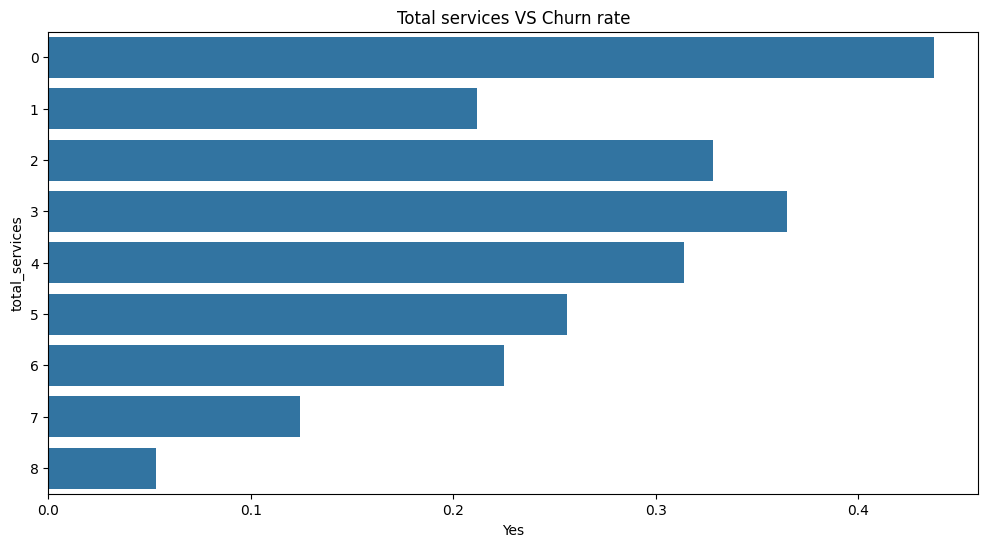

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(data=churn_by_services, x='Yes', y='total_services', orient='h')
plt.title('Total services VS Churn rate');

#### Comments:
* This analysis reveals that churn rate decreases with the increase of adoption in total services. That means customers are happy with more services though they have to pay more.

### Business Recommendation

* Push add-on services early (within first 3–6 months) to reduce early churn.
* Offer bundled discounts for new customers to accelerate adoption.
* Focus retention campaigns on customers with low tenure and low service count.

---
### Author Information
**Name:** [Apabrita Maity]  
**Date:** 2026-01-07  
**Role:** [Data Analyst | Data Scientist]

### Let's Connect!
If you have questions about this analysis or would like to collaborate, feel free to reach out:

*  **LinkedIn:** [LinkedIn](https://www.linkedin.com/in/apabritamaity/)
*  **GitHub:** [@apabritamaity](https://github.com/apabritamaity/data-analyst-portfolio)
*  **Email:** [contacttoapabrita@gmail.com](mailto:contacttoapabrita@gmail.com)